# Data Comparison

# Packages

In [136]:
import numpy as np
import pandas as pd
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from matplotlib_venn import venn2_unweighted, venn3_unweighted

# Directories

In [127]:
INPUT = 'D:/DDesktop/_work/data/canada/input/'
FEATURECOUNTS = INPUT + 'featureCounts/'
DEGS = INPUT + 'DEGs/'
DEG_GALAXY = DEGS + 'galaxy/'
DEG_BIOJUPIES = DEGS + 'biojupies/'

MIMICS = INPUT + 'mimics/'

OUTPUT = 'D:/DDesktop/_work/data/canada/output/'
COMPARISON = OUTPUT + 'comparison_data/'
TABULAR = OUTPUT + 'tabular/'

DEG_COMPARISON = COMPARISON + 'degs/'
PVAL_LOG = DEG_COMPARISON + 'pval_log/'
PVAL_TOP = DEG_COMPARISON + 'pval_top/'
LANDMARK = DEG_COMPARISON + 'landmark/'

# Functions

In [94]:
def file_to_list(path):
    '''
    Converts a .txt file to a list
    '''

    with open(f'{path}', 'r', encoding = 'utf-8') as f:
        list_file = [line.strip() for line in f]
    
    return list_file

def pickle_load(path: str, report: bool = False):
    '''
    Loads pickled data.
    '''

    with open(path, 'rb') as f:
        data = pickle.load(f)

    if report == True:
        if type(data) == nx.Graph:
            num_nodes = len(data.nodes)
            num_edges = len(data.edges)
            print('>> pickle_load')
            print(f'Pickled graph loaded w/ {num_nodes:,} nodes and {num_edges:,} edges')
            print()
        else:
            print('>> pickle_load')
            print(f'Pickled file loaded')
            print()

    return data


# Analysis

## DEGs

Two methods were used to extract DEGs

1. Galaxy DeSeq2 module

    - Timepoint treatment and vehicle control featureCount replicates

2. BioJupies

    - Timepoint treatment and vehicle control featureCount replicates
        

### Galaxy

#### DEGs

In [41]:
# Initialise dataframe
df_galaxy = pd.DataFrame()

# Set column names
list_columns = ['geneid', 'base_mean', 'log2fc', 'stderr', 'wald_stats', 'pval', 'padj']

# Iterate through files
for file in os.listdir(DEG_GALAXY):

    # Get timepoint
    timepoint = file.split('_')[0]
    # Get treatment
    treatment = file.split('_')[1]
    treatment = treatment.split('.')[0]

    # Load data
    df = pd.read_csv(DEG_GALAXY + file, sep = '\t', header = None)
    # Set columns
    df.columns = list_columns
    # Add columns
    df['timepoint'] = timepoint
    df['treatment'] = treatment
    # Concatenate data
    df_galaxy = pd.concat([df_galaxy, df])

df_galaxy.head()

,geneid,base_mean,log2fc,stderr,wald_stats,pval,padj,timepoint,treatment
0,JUN,43161.977799,4.988578,0.127476,39.133503,0.0,0.0,24h,halo
1,TXNIP,5484.986227,5.773350,0.140200,41.179261,0.0,0.0,24h,halo
2,H4C15,6983.983372,7.019016,0.147412,47.615012,0.0,0.0,24h,halo
3,H2BC21,15529.858961,8.463666,0.167111,50.646899,0.0,0.0,24h,halo
4,ATF3,18964.904147,8.001882,0.140470,56.965058,0.0,0.0,24h,halo


##### pval < 0.05 & abs(log2fc) > 1

In [124]:
# Filter df_galaxy
df_pval_log = df_galaxy[(df_galaxy['pval'] < 0.05) &
                        (abs(df_galaxy['log2fc']) > 1)]

# Iterate through timepoints
for timepoint in ['6h', '24h']:
    for treatment in ['halo', 'nita', 'paro']:

        # Filter data
        df = df_pval_log[(df_pval_log['timepoint'] == timepoint) &
                         (df_pval_log['treatment'] == treatment)]
        
        # Split data
        df_up = df[df['log2fc'] > 0]
        df_down = df[df['log2fc'] < 0]

        # Save lists
        df_up['geneid'].to_csv(PVAL_LOG + f'{timepoint}_{treatment}_up.txt', header = False, index = False)
        df_down['geneid'].to_csv(PVAL_LOG + f'{timepoint}_{treatment}_down.txt', header = False, index = False)

##### Top 2000 by pvalue

- This doesn't seem to filter by `pval` as DKK3 is present in 6h_nita signature on BioJupies L1000CDS2 report as overlapping in down 'signature', yet isn't pval significant

In [125]:
# Iterate through timepoints
for timepoint in ['6h', '24h']:
    for treatment in ['halo', 'nita', 'paro']:

        # Filter data
        df = df_galaxy[(df_galaxy['timepoint'] == timepoint) &
                       (df_galaxy['treatment'] == treatment)]
        
        # Sort from smallest pvalue
        df.sort_values(by = 'pval', ascending = True, inplace = True)
        # Take top 2000
        df = df.iloc[0:2000, :]
        # Split data
        df_up = df[df['log2fc'] > 0]
        df_down = df[df['log2fc'] < 0]

        # Save data
        df_up['geneid'].to_csv(PVAL_TOP + f'{timepoint}_{treatment}_up.txt', header = False, index = False)
        df_down['geneid'].to_csv(PVAL_TOP + f'{timepoint}_{treatment}_down.txt', header = False, index = False)

C:\Users\roman\AppData\Local\Temp\ipykernel_8292\3872020263.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values(by = 'pval', ascending = True, inplace = True)


##### Landmark DEGs - no filtering

In [126]:
# Load landmark data
df_landmark = pickle_load(OUTPUT + 'df_lincs_landmark.pkl')
# Get gene list
list_landmark = pd.unique(df_landmark['gene_name'])

# Iterate through timepoints
for timepoint in ['6h', '24h']:
    for treatment in ['halo', 'nita', 'paro']:

        # Filter data
        df = df_galaxy[(df_galaxy['timepoint'] == timepoint) &
                       (df_galaxy['treatment'] == treatment) &
                       (df_galaxy['geneid'].isin(list_landmark))]
        
        # Split data
        df_up = df[df['log2fc'] > 0]
        df_down = df[df['log2fc'] < 0]

        # Save data
        df_up['geneid'].to_csv(LANDMARK + f'{timepoint}_{treatment}_up.txt', header = False, index = False)
        df_down['geneid'].to_csv(LANDMARK + f'{timepoint}_{treatment}_down.txt', header = False, index = False)

#### Mimics

c:\Users\roman\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib_venn\_util.py:62: UserWarning: venn3_unweighted is deprecated. Use venn3 with the appropriate layout_algorithm instead.
  warnings.warn(


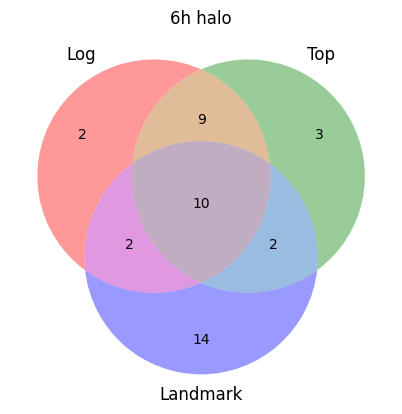

c:\Users\roman\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib_venn\_util.py:62: UserWarning: venn3_unweighted is deprecated. Use venn3 with the appropriate layout_algorithm instead.
  warnings.warn(


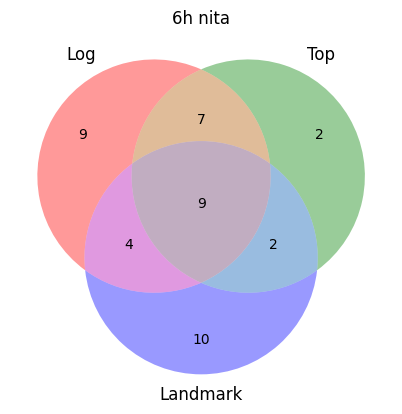

c:\Users\roman\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib_venn\_util.py:62: UserWarning: venn3_unweighted is deprecated. Use venn3 with the appropriate layout_algorithm instead.
  warnings.warn(


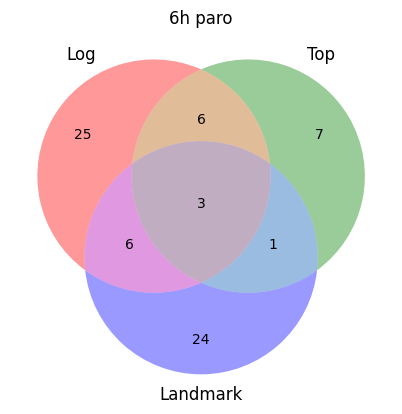

c:\Users\roman\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib_venn\_util.py:62: UserWarning: venn3_unweighted is deprecated. Use venn3 with the appropriate layout_algorithm instead.
  warnings.warn(


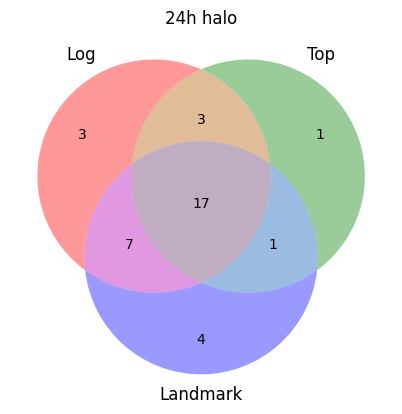

c:\Users\roman\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib_venn\_util.py:62: UserWarning: venn3_unweighted is deprecated. Use venn3 with the appropriate layout_algorithm instead.
  warnings.warn(


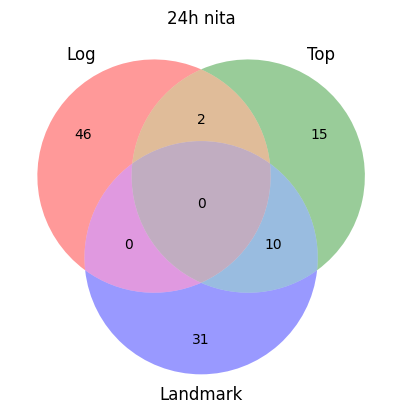

c:\Users\roman\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib_venn\_util.py:62: UserWarning: venn3_unweighted is deprecated. Use venn3 with the appropriate layout_algorithm instead.
  warnings.warn(


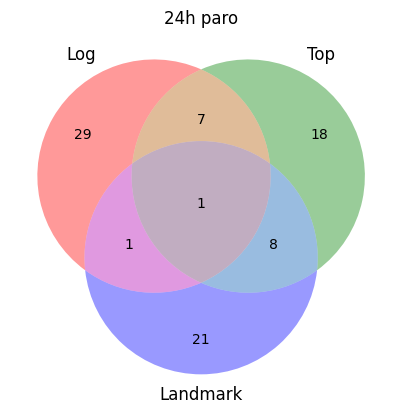

In [138]:
# Iterate through timepoints
for timepoint in ['6h', '24h']:
    for treatment in ['halo', 'nita', 'paro']:

        # Load data
        df_log = pd.read_csv(MIMICS + f'{timepoint}_{treatment}_galaxy_log.tsv', sep = '\t')
        df_top = pd.read_csv(MIMICS + f'{timepoint}_{treatment}_galaxy_top.tsv', sep = '\t')
        df_lmk = pd.read_csv(MIMICS + f'{timepoint}_{treatment}_galaxy_landmark.tsv', sep = '\t')

        # Extract sets
        set_log = set(df_log['Perturbation'])
        set_top = set(df_top['Perturbation'])
        set_lmk = set(df_lmk['Perturbation'])

        # Venn diagram
        plt.title(f'{timepoint} {treatment}')
        venn3_unweighted(subsets = [set_log, set_top, set_lmk], set_labels = ['Log', 'Top', 'Landmark'])
        plt.show()

### BioJupies

#### Data for DEGs

This section:

- Creates various timepoint-specific treatment vs vehicle control files from featureCounts files

In [23]:
list_files = [file for file in os.listdir(TABULAR) if '_CON_' not in file]
list_files = [entry for entry in list_files if '96h_' not in entry]
list_files = [entry for entry in list_files if '6h_' in entry or '24h_' in entry]
list_timepoints = ['6h', '24h']

# Iterate through tabular data
for timepoint in list_timepoints:
    
    # Define vehicle replicates
    df_vehicle = pd.read_csv(TABULAR + f'{timepoint}_inf_vehicle_1.tabular', sep = '\t')
    df_vehicle_2 = pd.read_csv(TABULAR + f'{timepoint}_inf_vehicle_2.tabular', sep = '\t')
    df_vehicle_3 = pd.read_csv(TABULAR + f'{timepoint}_inf_vehicle_3.tabular', sep = '\t')

    # Rename columns
    for df, name in zip([df_vehicle, df_vehicle_2, df_vehicle_3], [f'{timepoint}_inf_vehicle_1', f'{timepoint}_inf_vehicle_2', f'{timepoint}_inf_vehicle_3']):
        df.rename(columns = {'count' : name}, inplace = True)

    # Merge data frames
    for df in [df_vehicle_2, df_vehicle_3]:
        df_vehicle = pd.merge(df_vehicle, df, how = 'left', on = 'Geneid')

    # Iterate through treatments
    for treatment in ['halo', 'paro', 'nita']:
        
        # Define replicate data
        df_treatment = pd.read_csv(TABULAR + f'{timepoint}_inf_{treatment}_1.tabular', sep = '\t')
        df_treatment_2 = pd.read_csv(TABULAR + f'{timepoint}_inf_{treatment}_2.tabular', sep = '\t')
        df_treatment_3 = pd.read_csv(TABULAR + f'{timepoint}_inf_{treatment}_3.tabular', sep = '\t')

        # Rename columns
        for df, name in zip([df_treatment, df_treatment_2, df_treatment_3], [f'{timepoint}_inf_{treatment}_1', f'{timepoint}_inf_{treatment}_2', f'{timepoint}_inf_{treatment}_3']):
            df.rename(columns = {'count' : name}, inplace = True)
        
        # Merge treatment dataframes
        for df in [df_treatment_2, df_treatment_3]:
            df_treatment = pd.merge(df_treatment, df, how = 'left', on = 'Geneid')
        
        # Merge treatment and vehicle dataframes
        df_merge = pd.merge(df_vehicle, df_treatment, how = 'left', on = 'Geneid')
        # Set index
        df_merge.set_index('Geneid', inplace = True)

        # Save data
        df_merge.to_csv(COMPARISON + f'biojupies/{timepoint}_{treatment}.csv', index = True)

df_merge.head()

,24h_inf_vehicle_1,24h_inf_vehicle_2,24h_inf_vehicle_3,24h_inf_nita_1,24h_inf_nita_2,24h_inf_nita_3
Geneid,,,,,,
DDX11L1,0,0,0,0,0,0
WASH7P,272,314,296,345,261,219
MIR6859-1,1,4,4,3,6,10
MIR1302-2HG,1,0,0,0,0,0
MIR1302-2,0,0,0,0,0,0


#### DEGs

In [32]:
# Set file list
list_files = [file for file in os.listdir(DEG_BIOJUPIES) if '_sig' not in file]

# Initialise dataframe
df_bio = pd.DataFrame()

# Iterate through files
for file in list_files:

    # Get timepoint
    timepoint = file.split('_')[0]
    # Get treatment
    treatment = file.split('_')[1]
    treatment = treatment.split('.')[0]
    # Load data
    df = pd.read_csv(DEG_BIOJUPIES + file, sep = '\t')
    # Add columns
    df['timepoint'] = timepoint
    df['treatment'] = treatment
    # Concatenate data
    df_bio = pd.concat([df_bio, df])

# Show data
df_bio.head()

,gene_symbol,logFC,AveExpr,t,P.Value,adj.P.Val,B,timepoint,treatment
0,H2BC11,9.258832,5.336677,68.973823,1.352597e-16,2.030776e-12,26.898102,24h,halo
1,H2AC8,10.238707,5.237705,65.458609,2.485802e-16,2.030776e-12,26.478459,24h,halo
2,H2BC12,7.251895,8.409591,61.399440,5.233913e-16,2.558252e-12,26.587199,24h,halo
3,ATF3,7.965307,6.678568,60.458966,6.262934e-16,2.558252e-12,26.145245,24h,halo
4,H2AC6,7.612767,6.727608,58.024182,1.010006e-15,3.300499e-12,25.794902,24h,halo


##### pval < 0.05 & abs(log2fc) > 1

In [141]:
# Filter df_bio
df_pval_log = df_bio[(df_bio['P.Value'] < 0.05) &
                     (abs(df_bio['logFC']) > 1)]

# Iterate through timepoints
for timepoint in ['6h', '24h']:
    for treatment in ['halo', 'nita', 'paro']:

        # Filter data
        df = df_pval_log[(df_pval_log['timepoint'] == timepoint) &
                         (df_pval_log['treatment'] == treatment)]
        
        # Split data
        df_up = df[df['logFC'] > 0]
        df_down = df[df['logFC'] < 0]

        # Save lists
        df_up['gene_symbol'].to_csv(PVAL_LOG + f'bio_{timepoint}_{treatment}_up.txt', header = False, index = False)
        df_down['gene_symbol'].to_csv(PVAL_LOG + f'bio_{timepoint}_{treatment}_down.txt', header = False, index = False)

##### Top 2000 by pvalue

In [142]:
# Iterate through timepoints
for timepoint in ['6h', '24h']:
    for treatment in ['halo', 'nita', 'paro']:

        # Filter data
        df = df_bio[(df_bio['timepoint'] == timepoint) &
                    (df_bio['treatment'] == treatment)]
        
        # Sort from smallest pvalue
        df.sort_values(by = 'P.Value', ascending = True, inplace = True)
        # Take top 2000
        df = df.iloc[0:2000, :]
        # Split data
        df_up = df[df['logFC'] > 0]
        df_down = df[df['logFC'] < 0]

        # Save data
        df_up['gene_symbol'].to_csv(PVAL_TOP + f'bio_{timepoint}_{treatment}_up.txt', header = False, index = False)
        df_down['gene_symbol'].to_csv(PVAL_TOP + f'bio_{timepoint}_{treatment}_down.txt', header = False, index = False)

C:\Users\roman\AppData\Local\Temp\ipykernel_8292\970657516.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values(by = 'P.Value', ascending = True, inplace = True)


##### Landmark DEGs - no filtering

In [144]:
# Load landmark data
df_landmark = pickle_load(OUTPUT + 'df_lincs_landmark.pkl')
# Get gene list
list_landmark = pd.unique(df_landmark['gene_name'])

# Iterate through timepoints
for timepoint in ['6h', '24h']:
    for treatment in ['halo', 'nita', 'paro']:

        # Filter data
        df = df_bio[(df_bio['timepoint'] == timepoint) &
                    (df_bio['treatment'] == treatment) &
                    (df_bio['gene_symbol'].isin(list_landmark))]
        
        # Split data
        df_up = df[df['logFC'] > 0]
        df_down = df[df['logFC'] < 0]

        # Save data
        df_up['gene_symbol'].to_csv(LANDMARK + f'bio_{timepoint}_{treatment}_up.txt', header = False, index = False)
        df_down['gene_symbol'].to_csv(LANDMARK + f'bio_{timepoint}_{treatment}_down.txt', header = False, index = False)

#### Mimics